In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from typing import Union
import matplotlib.pyplot as plt
from matplotlib import rcParams
# 首先配置字体信息
config = {
    "font.family": 'serif',
    "font.size": 12,
    "mathtext.fontset": 'stix',
    "font.serif": ['SimSun'],
}
rcParams.update(config)
def generate_time_comparison_plot(
    results_dir: Union[str, Path],
    output_path: Union[str, Path],
    max_epoch: int = 500,
    figsize: tuple = (10, 6),
    dpi: int = 300
) -> None:
    """
    生成联邦学习算法耗时对比箱型图
    
    :param results_dir: 包含算法结果的根目录路径
    :param output_path: 图片输出路径（需包含文件名和扩展名）
    :param max_epoch: 最大考虑的训练轮次（默认500）
    :param figsize: 图表尺寸（默认(10,6)）
    :param dpi: 图片分辨率（默认300）
    """
    # 转换为Path对象
    results_dir = Path(results_dir)
    output_path = Path(output_path)
    
    # 算法目录映射
    algorithms = {
        "FedAvg": "fedavg-cnn-dir0.1",
        "FedDocs": "FedDocs-CNN-dir0.1",
        "FedLC": "fedlc-cnn-dir0.1",
        "PyramidFL": "PyramidFL-cnn-dir0.1"
    }

    # 读取数据
    all_data = []
    for algo, path in algorithms.items():
        try:
            df = pd.read_csv(results_dir / path / "epoch_results_with_cumtime.csv")
            df = df.query(f"epoch <= {max_epoch}").assign(algorithm=algo)
            all_data.append(df[['epoch', 'sim_round_time', 'algorithm']])
        except Exception as e:
            print(f"【警告】跳过 {algo}: {str(e)}")
            continue

    if not all_data:
        print("错误：没有成功加载任何数据")
        return

    # 合并数据
    combined = pd.concat(all_data, ignore_index=True)

    # 初始化画布
    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    # 绘制箱型图
    ax = sns.boxplot(
        x='algorithm',
        y='sim_round_time',
        data=combined,
        width=0.6,
        showfliers=False
    )

    # 图表装饰
    ax.set_title(f'算法耗时对比 (1-{max_epoch} Epochs)', fontsize=14, pad=15)
    ax.set_xlabel('算法名称', fontsize=12, labelpad=10)
    ax.set_ylabel('单轮耗时（秒）', fontsize=12, labelpad=10)
    plt.xticks(fontsize=10)
    plt.grid(axis='y', alpha=0.6)

    # 确保输出目录存在
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    # 保存图表
    plt.tight_layout()
    plt.savefig(output_path, dpi=dpi, bbox_inches='tight')
    print(f"图表已保存至: {output_path.resolve()}")
    plt.close()

# 使用示例
if __name__ == "__main__":
    # 设置中文显示（Windows）
    # plt.rcParams['font.sans-serif'] = ['simsun']
    plt.rcParams['axes.unicode_minus'] = False
    
    generate_time_comparison_plot(
        results_dir="/home/ypguo/async-FL/src/results/Exp2025-FashionMNIST-Dir0.1",
        output_path="./sim_time_FashionMNIST-Dir0.1_comparison.png",
        max_epoch=300,
        figsize=(12, 7)
    )
    # generate_time_comparison_plot(
    #     results_dir="/home/ypguo/async-FL/src/results/Exp2025-FashionMNIST-Dir0.5",
    #     output_path="./sim_time_FashionMNIST-Dir0.5_comparison.png",
    #     max_epoch=300,
    #     figsize=(12, 7)
    # )   

/tmp/ipykernel_1605121/1233691687.py:86: UserWarning: Glyph 31639 (\N{CJK UNIFIED IDEOGRAPH-7B97}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1605121/1233691687.py:86: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1605121/1233691687.py:86: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1605121/1233691687.py:86: UserWarning: Glyph 31216 (\N{CJK UNIFIED IDEOGRAPH-79F0}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1605121/1233691687.py:86: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1605121/1233691687.py:86: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1605121/1233691687.py:86: UserWarning: Glyph 32791 (\N{CJK UNIFIED IDEOGRAPH-8017}) missing from curren

图表已保存至: /home/ypguo/async-FL/画图/sim_time_FashionMNIST-Dir0.1_comparison.png


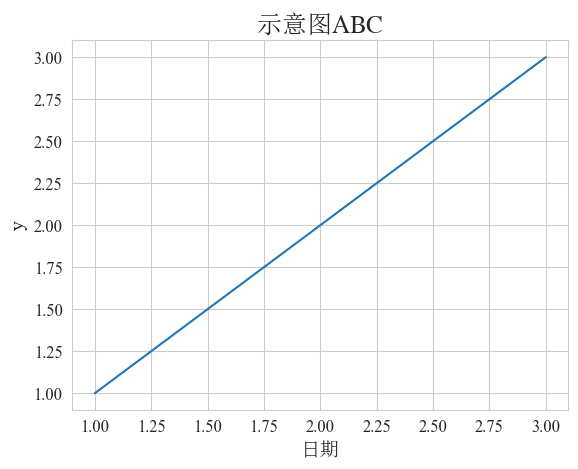

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 首先配置字体信息
config = {
    "font.family": 'serif',
    "font.size": 12,
    "mathtext.fontset": 'stix',
    "font.serif": ['SimSun'],
}
rcParams.update(config)

x = [1, 2, 3]
y = [1, 2, 3]

# 将刻度显示设置为新罗马字体
plt.xticks(fontproperties='Times New Roman')
plt.yticks(fontproperties='Times New Roman')

# 中英文字符混合
plt.title('示意图$\mathrm{ABC}$', size=18)
# 仅包含中文字符
plt.xlabel('日期', size=14)
# 仅包含英文字符
plt.ylabel('y', fontproperties='Times New Roman', size=14)

plt.plot(x, y)
plt.show()



跳过 FedAGSA-CNN-dir0.5-lambda0-epsilon100-target0.1: 未找到 epoch_results_with_cumtime.csv 文件
成功加载 fedavg-cnn-dir0.5 的数据
成功加载 fedlc-cnn-dir0.5 的数据
成功加载 PyramidFL-cnn-dir0.5 的数据
成功加载 FedDocs-CNN-dir0.5 的数据
成功加载 FedAGSA-CNN-dir0.5 的数据
跳过 FedAGSA-CNN-dir0.5-adam-lr0.001: 未找到 epoch_results_with_cumtime.csv 文件
保存图表: /home/ypguo/async-FL/src/results/Exp2025-FashionMNIST-Dir0.5/Exp2025-FashionMNIST-Dir0.5_accuracy_vs_epoch_300.png
保存图表: /home/ypguo/async-FL/src/results/Exp2025-FashionMNIST-Dir0.5/Exp2025-FashionMNIST-Dir0.5_accuracy_vs_time_300.png
绘图完成！

成功加载的算法: 5
跳过的算法: 2


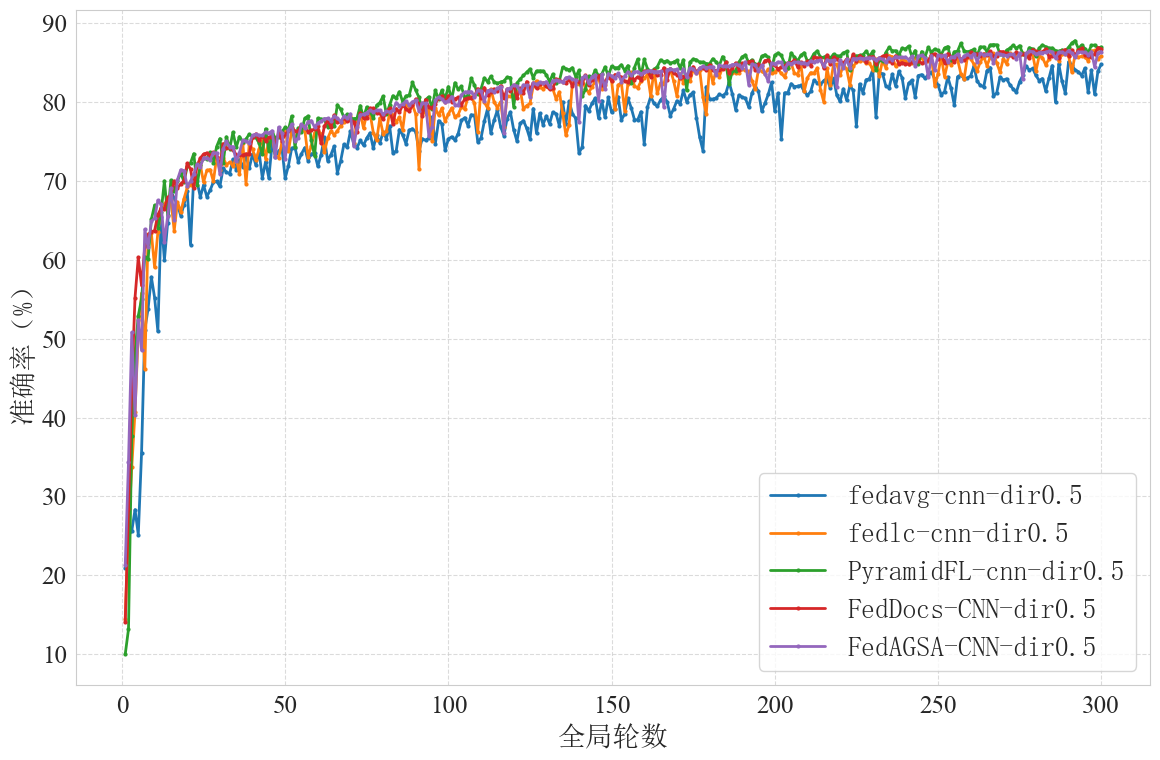

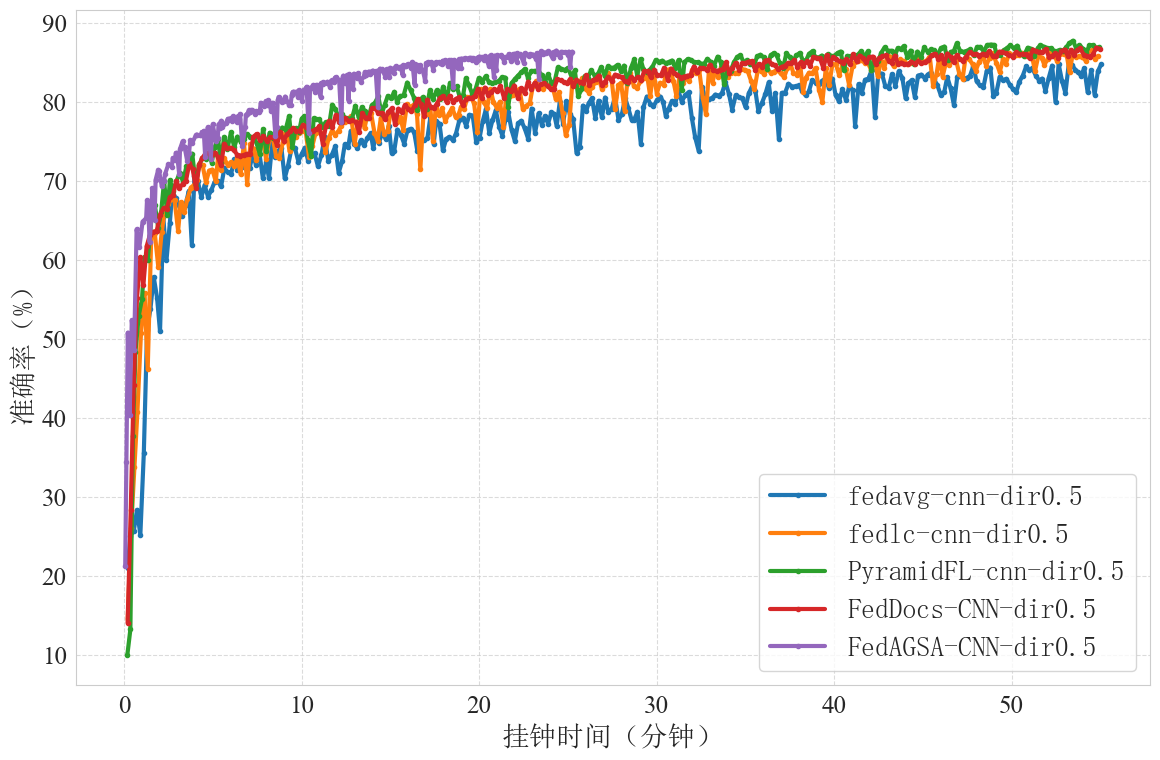

In [17]:

# 使用示例
if __name__ == "__main__":
    # 主目录路径
    main_dir = '/home/ypguo/async-FL/src/results/Exp2025-FashionMNIST-Dir0.5'
    
    # 调用函数生成图表
    result = plot_federated_learning_performance(
        main_dir=main_dir,
        max_time=60,  # 60分钟
        total_rounds=300,
        save_epoch_plot=True,
        save_time_plot=True,
        fig_size=(12, 8),
        dpi=300,
        dataset_name="Fashion-MNIST",
        dir_alpha="0.5"
    )
    
    # 输出加载情况总结
    print(f"\n成功加载的算法: {len(result['loaded_algorithms'])}")
    print(f"跳过的算法: {len(result['skipped_algorithms'])}")